In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd

path = "/content/drive/MyDrive/BCAM/distr_sol_pv_segm_embeddings_v2.npz"

data = np.load(path, allow_pickle=True)

X = data["features"].astype(np.float32)
y = data["label"].astype(int)

print("X:", X.shape)
print("y:", y.shape)
print("\nDistribución de clases:")
print(pd.Series(y).value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X: (20976, 64)
y: (20976,)

Distribución de clases:
1    10683
0    10293
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("train:", X_train.shape, np.unique(y_train, return_counts=True))
print("valid:", X_valid.shape, np.unique(y_valid, return_counts=True))
print("test :", X_test.shape, np.unique(y_test, return_counts=True))

train: (14683, 64) (array([0, 1]), array([7205, 7478]))
valid: (3146, 64) (array([0, 1]), array([1544, 1602]))
test : (3147, 64) (array([0, 1]), array([1544, 1603]))


,PCA,Varianza_individual,Varianza_acumulada
0,1,0.697802,0.697802
1,2,0.147782,0.845584
2,3,0.067400,0.912984
3,4,0.038556,0.951539
4,5,0.014278,0.965817
...,...,...,...
59,60,0.000006,0.999985
60,61,0.000005,0.999989
61,62,0.000004,0.999993
62,63,0.000004,0.999997


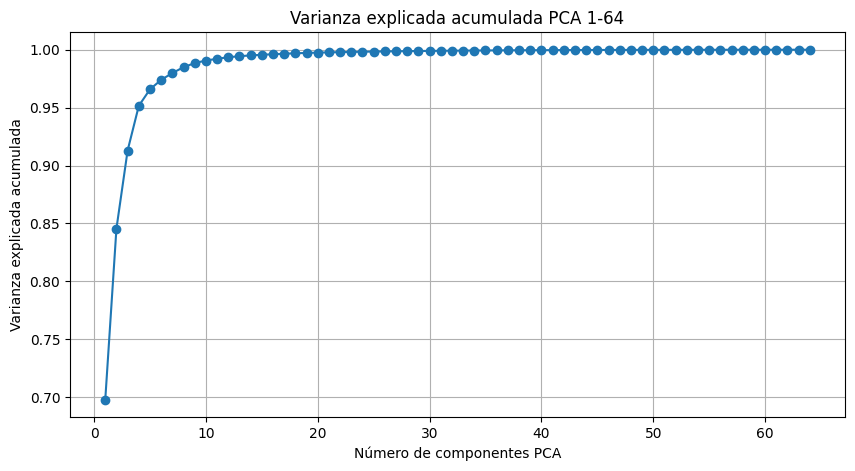

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_full = PCA(n_components=64)
pca_full.fit(X_train_scaled)

df_var = pd.DataFrame({
    "PCA": np.arange(1, 65),
    "Varianza_individual": pca_full.explained_variance_ratio_,
    "Varianza_acumulada": np.cumsum(pca_full.explained_variance_ratio_)
})

display(df_var)

plt.figure(figsize=(10, 5))
plt.plot(df_var["PCA"], df_var["Varianza_acumulada"], marker="o")
plt.xlabel("Número de componentes PCA")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada PCA 1-64")
plt.grid(True)
plt.show()

Reconstrucción PCA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,PCA,MSE_train,MSE_test,Varianza_acumulada
0,1,3.021977e-01,2.986518e-01,0.697802
1,2,1.544157e-01,1.585419e-01,0.845584
2,3,8.701625e-02,8.923903e-02,0.912984
3,4,4.846068e-02,4.898691e-02,0.951539
4,5,3.418268e-02,3.432694e-02,0.965817
...,...,...,...,...
59,60,1.534880e-05,1.577837e-05,0.999985
60,61,1.060422e-05,1.129075e-05,0.999989
61,62,6.533990e-06,7.029011e-06,0.999993
62,63,2.649293e-06,2.771382e-06,0.999997


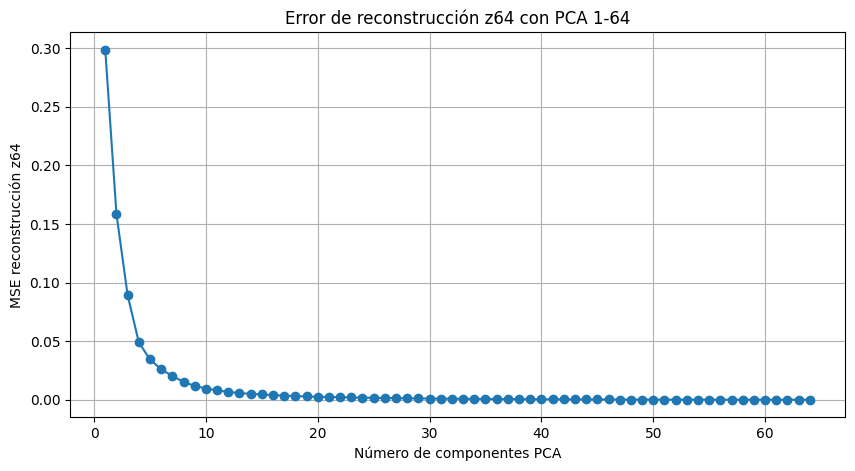

In [4]:
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

recon_results = []

for k in tqdm(range(1, 65), desc="Reconstrucción PCA 1-64"):
    pca = PCA(n_components=k)

    Z_train = pca.fit_transform(X_train_scaled)
    X_train_rec = pca.inverse_transform(Z_train)

    Z_test = pca.transform(X_test_scaled)
    X_test_rec = pca.inverse_transform(Z_test)

    recon_results.append({
        "PCA": k,
        "MSE_train": mean_squared_error(X_train_scaled, X_train_rec),
        "MSE_test": mean_squared_error(X_test_scaled, X_test_rec),
        "Varianza_acumulada": np.sum(pca.explained_variance_ratio_)
    })

df_recon = pd.DataFrame(recon_results)

display(df_recon)

plt.figure(figsize=(10, 5))
plt.plot(df_recon["PCA"], df_recon["MSE_test"], marker="o")
plt.xlabel("Número de componentes PCA")
plt.ylabel("MSE reconstrucción z64")
plt.title("Error de reconstrucción z64 con PCA 1-64")
plt.grid(True)
plt.show()

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
from tqdm.auto import tqdm

results_svm = []

for k in tqdm(range(1, 65), desc="SVM RBF PCA 1-64"):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k)),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=False,
            cache_size=1000
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = model.decision_function(X_test)

    results_svm.append({
        "Model": "SVM_RBF",
        "PCA": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_score)
    })

df_svm = pd.DataFrame(results_svm)

display(df_svm)

print("Mejor SVM por AUC:")
display(df_svm.loc[[df_svm["AUC"].idxmax()]])

SVM RBF PCA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,PCA,Acc,F1,bAcc,AUC
0,SVM_RBF,1,0.793454,0.789508,0.794085,0.838873
1,SVM_RBF,2,0.872895,0.861496,0.874745,0.925457
2,SVM_RBF,3,0.877344,0.866897,0.879124,0.933171
3,SVM_RBF,4,0.882428,0.872940,0.884138,0.931693
4,SVM_RBF,5,0.888465,0.879836,0.890124,0.935190
...,...,...,...,...,...,...
59,SVM_RBF,60,0.892596,0.885034,0.894144,0.936673
60,SVM_RBF,61,0.892596,0.885034,0.894144,0.936656
61,SVM_RBF,62,0.893232,0.885792,0.894767,0.936658
62,SVM_RBF,63,0.893232,0.885792,0.894767,0.936611


Mejor SVM por AUC:


,Model,PCA,Acc,F1,bAcc,AUC
6,SVM_RBF,7,0.888783,0.880383,0.890413,0.938154


In [10]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(df_svm.to_string(index=False))

  Model  PCA      Acc       F1     bAcc      AUC
SVM_RBF    1 0.793454 0.789508 0.794085 0.838873
SVM_RBF    2 0.872895 0.861496 0.874745 0.925457
SVM_RBF    3 0.877344 0.866897 0.879124 0.933171
SVM_RBF    4 0.882428 0.872940 0.884138 0.931693
SVM_RBF    5 0.888465 0.879836 0.890124 0.935190
SVM_RBF    6 0.888147 0.879617 0.889789 0.937669
SVM_RBF    7 0.888783 0.880383 0.890413 0.938154
SVM_RBF    8 0.889101 0.880847 0.890713 0.935498
SVM_RBF    9 0.889418 0.880985 0.891060 0.933183
SVM_RBF   10 0.889101 0.880684 0.890736 0.932381
SVM_RBF   11 0.889101 0.880684 0.890736 0.931106
SVM_RBF   12 0.890372 0.882132 0.891996 0.933604
SVM_RBF   13 0.889736 0.881449 0.891360 0.933162
SVM_RBF   14 0.890372 0.882212 0.891984 0.932445
SVM_RBF   15 0.891961 0.884196 0.893532 0.933040
SVM_RBF   16 0.891325 0.883515 0.892896 0.933058
SVM_RBF   17 0.893867 0.886317 0.895427 0.934065
SVM_RBF   18 0.893867 0.886317 0.895427 0.934135
SVM_RBF   19 0.893549 0.886016 0.895103 0.934176
SVM_RBF   20 0.89386

In [6]:
from sklearn.ensemble import RandomForestClassifier
from tqdm.auto import tqdm

results_rf = []

for k in tqdm(range(1, 65), desc="Random Forest PCA 1-64"):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k)),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_rf.append({
        "Model": "Random_Forest",
        "PCA": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_rf = pd.DataFrame(results_rf)

display(df_rf)

print("Mejor Random Forest por AUC:")
display(df_rf.loc[[df_rf["AUC"].idxmax()]])

Random Forest PCA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,PCA,Acc,F1,bAcc,AUC
0,Random_Forest,1,0.702574,0.703422,0.702767,0.807961
1,Random_Forest,2,0.857960,0.853778,0.858798,0.923871
2,Random_Forest,3,0.877661,0.873646,0.878566,0.935234
3,Random_Forest,4,0.887512,0.883322,0.888497,0.938300
4,Random_Forest,5,0.886876,0.882119,0.887945,0.941993
...,...,...,...,...,...,...
59,Random_Forest,60,0.876072,0.870690,0.877161,0.938014
60,Random_Forest,61,0.880521,0.875826,0.881540,0.938468
61,Random_Forest,62,0.878297,0.873388,0.879333,0.937903
62,Random_Forest,63,0.877661,0.872643,0.878709,0.938275


Mejor Random Forest por AUC:


,Model,PCA,Acc,F1,bAcc,AUC
8,Random_Forest,9,0.884652,0.878798,0.885869,0.945281


In [11]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(df_rf.to_string(index=False))

        Model  PCA      Acc       F1     bAcc      AUC
Random_Forest    1 0.702574 0.703422 0.702767 0.807961
Random_Forest    2 0.857960 0.853778 0.858798 0.923871
Random_Forest    3 0.877661 0.873646 0.878566 0.935234
Random_Forest    4 0.887512 0.883322 0.888497 0.938300
Random_Forest    5 0.886876 0.882119 0.887945 0.941993
Random_Forest    6 0.889101 0.884169 0.890212 0.943228
Random_Forest    7 0.888465 0.883659 0.889552 0.943338
Random_Forest    8 0.884017 0.878858 0.885126 0.944475
Random_Forest    9 0.884652 0.878798 0.885869 0.945281
Random_Forest   10 0.887830 0.882216 0.889036 0.944835
Random_Forest   11 0.887194 0.881627 0.888388 0.944620
Random_Forest   12 0.885605 0.879679 0.886840 0.942971
Random_Forest   13 0.885923 0.880214 0.887129 0.943066
Random_Forest   14 0.886241 0.880984 0.887381 0.942733
Random_Forest   15 0.883063 0.877415 0.884238 0.942051
Random_Forest   16 0.887194 0.881231 0.888448 0.941746
Random_Forest   17 0.887194 0.881390 0.888424 0.941208
Random_For

In [7]:
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm

results_lr = []

for k in tqdm(range(1, 65), desc="Logistic Regression PCA 1-64"):

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k)),
        ("clf", LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_lr.append({
        "Model": "Logistic_Regression",
        "PCA": k,
        "Acc": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "bAcc": balanced_accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

df_lr = pd.DataFrame(results_lr)

display(df_lr)

print("Mejor Logistic Regression por AUC:")
display(df_lr.loc[[df_lr["AUC"].idxmax()]])

Logistic Regression PCA 1-64:   0%|          | 0/64 [00:00<?, ?it/s]

,Model,PCA,Acc,F1,bAcc,AUC
0,Logistic_Regression,1,0.794407,0.786398,0.795390,0.873362
1,Logistic_Regression,2,0.872259,0.863729,0.873740,0.917117
2,Logistic_Regression,3,0.886876,0.879973,0.888267,0.933343
3,Logistic_Regression,4,0.886241,0.879380,0.887619,0.931453
4,Logistic_Regression,5,0.891325,0.884693,0.892717,0.943613
...,...,...,...,...,...,...
59,Logistic_Regression,60,0.893232,0.887475,0.894505,0.947780
60,Logistic_Regression,61,0.893867,0.888220,0.895129,0.947766
61,Logistic_Regression,62,0.893549,0.887772,0.894829,0.947873
62,Logistic_Regression,63,0.892914,0.887178,0.894181,0.947712


Mejor Logistic Regression por AUC:


,Model,PCA,Acc,F1,bAcc,AUC
32,Logistic_Regression,33,0.896092,0.890379,0.897384,0.948609


In [12]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(df_lr.to_string(index=False))

              Model  PCA      Acc       F1     bAcc      AUC
Logistic_Regression    1 0.794407 0.786398 0.795390 0.873362
Logistic_Regression    2 0.872259 0.863729 0.873740 0.917117
Logistic_Regression    3 0.886876 0.879973 0.888267 0.933343
Logistic_Regression    4 0.886241 0.879380 0.887619 0.931453
Logistic_Regression    5 0.891325 0.884693 0.892717 0.943613
Logistic_Regression    6 0.887194 0.880512 0.888555 0.944423
Logistic_Regression    7 0.889736 0.883283 0.891086 0.944694
Logistic_Regression    8 0.889101 0.882531 0.890462 0.944726
Logistic_Regression    9 0.889101 0.882531 0.890462 0.944491
Logistic_Regression   10 0.888147 0.881800 0.889467 0.944162
Logistic_Regression   11 0.887830 0.881345 0.889167 0.943881
Logistic_Regression   12 0.889736 0.883126 0.891110 0.944550
Logistic_Regression   13 0.890054 0.883345 0.891446 0.945277
Logistic_Regression   14 0.890372 0.883877 0.891734 0.944566
Logistic_Regression   15 0.891325 0.885081 0.892658 0.945317
Logistic_Regression   16

In [13]:
df_all = pd.concat([df_svm, df_rf, df_lr], ignore_index=True)

display(df_all)

print("Mejor resultado por modelo:")
display(
    df_all.loc[df_all.groupby("Model")["AUC"].idxmax()]
    .sort_values("AUC", ascending=False)
)

,Model,PCA,Acc,F1,bAcc,AUC
0,SVM_RBF,1,0.793454,0.789508,0.794085,0.838873
1,SVM_RBF,2,0.872895,0.861496,0.874745,0.925457
2,SVM_RBF,3,0.877344,0.866897,0.879124,0.933171
3,SVM_RBF,4,0.882428,0.872940,0.884138,0.931693
4,SVM_RBF,5,0.888465,0.879836,0.890124,0.935190
5,SVM_RBF,6,0.888147,0.879617,0.889789,0.937669
6,SVM_RBF,7,0.888783,0.880383,0.890413,0.938154
7,SVM_RBF,8,0.889101,0.880847,0.890713,0.935498
8,SVM_RBF,9,0.889418,0.880985,0.891060,0.933183
9,SVM_RBF,10,0.889101,0.880684,0.890736,0.932381


Mejor resultado por modelo:


,Model,PCA,Acc,F1,bAcc,AUC
160,Logistic_Regression,33,0.896092,0.890379,0.897384,0.948609
72,Random_Forest,9,0.884652,0.878798,0.885869,0.945281
6,SVM_RBF,7,0.888783,0.880383,0.890413,0.938154


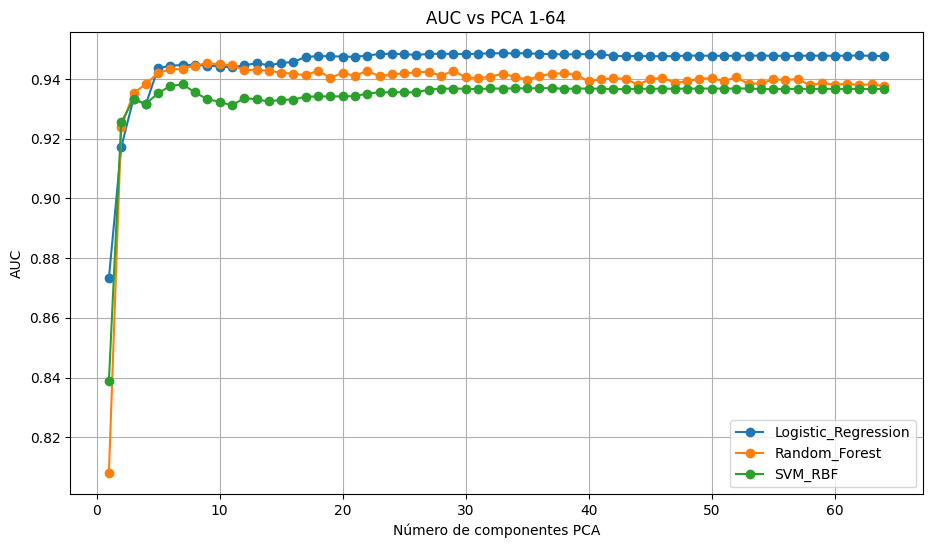

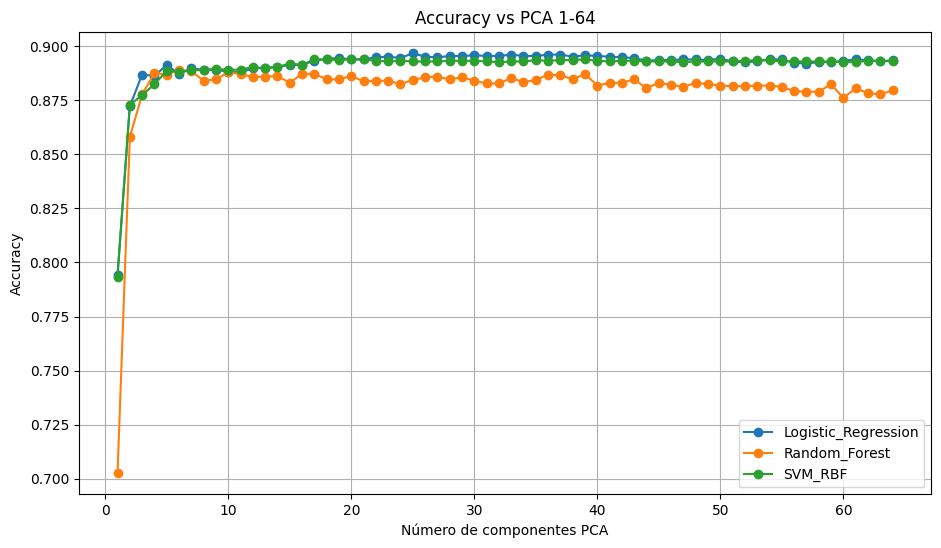

In [14]:
plt.figure(figsize=(11, 6))

for model_name, df_m in df_all.groupby("Model"):
    plt.plot(df_m["PCA"], df_m["AUC"], marker="o", label=model_name)

plt.xlabel("Número de componentes PCA")
plt.ylabel("AUC")
plt.title("AUC vs PCA 1-64")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(11, 6))

for model_name, df_m in df_all.groupby("Model"):
    plt.plot(df_m["PCA"], df_m["Acc"], marker="o", label=model_name)

plt.xlabel("Número de componentes PCA")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA 1-64")
plt.grid(True)
plt.legend()
plt.show()